<a href="https://colab.research.google.com/github/isumitsr/probabilistic-safety-stock/blob/develop/AAI_USD_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1: Setup and Mount Google Drive**

In [1]:
# ============================================================
# M5 Forecasting - Full EDA & Preprocessing Pipeline
# ============================================================

# Mount Google Drive (upload your CSV files to a folder first)
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 14

# --- SET YOUR DATA PATH HERE ---
DATA_PATH = "/content/drive/MyDrive/AAI_USD_P1/m5-forecasting-accuracy"   # <-- change if needed

print("Files in directory:")
for f in os.listdir(DATA_PATH):
    print("  ", f)

Mounted at /content/drive
Files in directory:
   calendar.csv
   sales_train_evaluation.csv
   sales_train_validation.csv
   sample_submission.csv
   sell_prices.csv


**Cell 2: Load All Datasets**

In [2]:
# Load the five M5 files
sales_eval  = pd.read_csv(f"{DATA_PATH}/sales_train_evaluation.csv")
sales_val   = pd.read_csv(f"{DATA_PATH}/sales_train_validation.csv")
calendar    = pd.read_csv(f"{DATA_PATH}/calendar.csv", parse_dates=['date'])
prices      = pd.read_csv(f"{DATA_PATH}/sell_prices.csv")
sample_sub  = pd.read_csv(f"{DATA_PATH}/sample_submission.csv")

print("Loaded shapes:")
print("  sales_train_evaluation:", sales_eval.shape)
print("  sales_train_validation:", sales_val.shape)
print("  calendar              :", calendar.shape)
print("  sell_prices           :", prices.shape)
print("  sample_submission     :", sample_sub.shape)

Loaded shapes:
  sales_train_evaluation: (30490, 1947)
  sales_train_validation: (30490, 1919)
  calendar              : (1969, 14)
  sell_prices           : (6841121, 4)
  sample_submission     : (60980, 29)


**Cell 3: Record Counts, Columns, Date Coverage, Identifiers**

In [3]:
def describe_df(name, df):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns)[:15], "... (truncated)" if df.shape[1] > 15 else "")
    print("\nDtypes (head):")
    print(df.dtypes.head(10))
    print("\nNull counts (top 10):")
    print(df.isnull().sum().sort_values(ascending=False).head(10))

describe_df("sales_train_evaluation", sales_eval)
describe_df("sales_train_validation", sales_val)
describe_df("calendar", calendar)
describe_df("sell_prices", prices)

# Date coverage
print("\n📅 Calendar Date Coverage:")
print("  Min date :", calendar['date'].min())
print("  Max date :", calendar['date'].max())
print("  Total days:", calendar['date'].nunique())

# Identifiers
print("\n🔑 Unique identifiers:")
print("  Stores     :", sales_eval['store_id'].nunique(), sorted(sales_eval['store_id'].unique()))
print("  States     :", sales_eval['state_id'].nunique(), sorted(sales_eval['state_id'].unique()))
print("  Categories :", sales_eval['cat_id'].nunique(),   sorted(sales_eval['cat_id'].unique()))
print("  Departments:", sales_eval['dept_id'].nunique())
print("  Items      :", sales_eval['item_id'].nunique())
print("  Series (item-store combos):", sales_eval[['item_id','store_id']].drop_duplicates().shape[0])


sales_train_evaluation
Shape: (30490, 1947)
Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9'] ... (truncated)

Dtypes (head):
id          object
item_id     object
dept_id     object
cat_id      object
store_id    object
state_id    object
d_1          int64
d_2          int64
d_3          int64
d_4          int64
dtype: object

Null counts (top 10):
d_1941      0
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
d_1         0
d_2         0
d_3         0
dtype: int64

sales_train_validation
Shape: (30490, 1919)
Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9'] ... (truncated)

Dtypes (head):
id          object
item_id     object
dept_id     object
cat_id      object
store_id    object
state_id    object
d_1          int64
d_2          int64
d_3          int64
d_4          int64
dtype:

**Cell 4: Series Selection Rules (BEFORE looking at model results)**

In [4]:
# ---- Selection Rules (defined a priori) ----
TARGET_STORES = ['CA_1', 'TX_1', 'WI_1']    # 3 stores across states
TARGET_CATS   = ['FOODS', 'HOUSEHOLD', 'HOBBIES']  # all 3 categories

# Subset rows
sel = sales_eval[sales_eval['store_id'].isin(TARGET_STORES) &
                 sales_eval['cat_id'].isin(TARGET_CATS)].copy()
print("After store+category filter:", sel.shape)

# Compute zero-rate (intermittency) on the training window (d_1 .. d_1913)
d_cols_train = [c for c in sales_eval.columns if c.startswith('d_') and int(c[2:]) <= 1913]
sel['zero_rate'] = (sel[d_cols_train] == 0).mean(axis=1)

# Keep items whose zero_rate is between 10% and 70% (avoids all-zero and overly dense)
sel = sel[(sel['zero_rate'] >= 0.10) & (sel['zero_rate'] <= 0.70)].copy()
print("After zero-rate filter      :", sel.shape)

# Take up to 3 items per (store, cat) for a manageable, balanced set
sel = (sel.sort_values('zero_rate')
          .groupby(['store_id','cat_id'], group_keys=False)
          .head(3)
          .reset_index(drop=True))

print("\nSelected series count:", sel.shape[0])
print(sel[['store_id','cat_id','item_id','zero_rate']].to_string(index=False))

# Save the "unmelted" selection for later
selected_meta = sel[['item_id','store_id','cat_id','dept_id','state_id','zero_rate']].copy()

After store+category filter: (9147, 1947)
After zero-rate filter      : (4036, 1948)

Selected series count: 27
store_id    cat_id         item_id  zero_rate
    TX_1     FOODS     FOODS_3_672   0.100366
    TX_1     FOODS     FOODS_2_276   0.101411
    CA_1     FOODS     FOODS_3_232   0.102980
    CA_1     FOODS     FOODS_3_756   0.102980
    CA_1     FOODS     FOODS_3_695   0.104548
    TX_1     FOODS     FOODS_3_681   0.105071
    TX_1 HOUSEHOLD HOUSEHOLD_1_319   0.106639
    WI_1     FOODS     FOODS_3_702   0.108207
    CA_1 HOUSEHOLD HOUSEHOLD_1_294   0.117616
    WI_1 HOUSEHOLD HOUSEHOLD_1_294   0.117616
    TX_1 HOUSEHOLD HOUSEHOLD_1_234   0.117616
    TX_1 HOUSEHOLD HOUSEHOLD_1_294   0.118662
    TX_1   HOBBIES   HOBBIES_1_323   0.119707
    WI_1     FOODS     FOODS_2_276   0.120753
    WI_1   HOBBIES   HOBBIES_1_330   0.122844
    CA_1   HOBBIES   HOBBIES_1_254   0.123366
    WI_1 HOUSEHOLD HOUSEHOLD_1_198   0.124412
    WI_1     FOODS     FOODS_3_202   0.124935
    CA_1 HOUSE

**Cell 5: Reshape (Melt) Daily Sales into Long Format**

In [5]:
# Identify all d_ columns
d_cols = [c for c in sel.columns if c.startswith('d_')]

# Melt wide -> long
long_df = sel.melt(
    id_vars=['id','item_id','dept_id','cat_id','store_id','state_id','zero_rate'],
    value_vars=d_cols,
    var_name='d',
    value_name='sales'
)

print("Long shape:", long_df.shape)
print(long_df.head())

Long shape: (52407, 9)
                            id      item_id  dept_id cat_id store_id state_id  \
0  FOODS_3_672_TX_1_evaluation  FOODS_3_672  FOODS_3  FOODS     TX_1       TX   
1  FOODS_2_276_TX_1_evaluation  FOODS_2_276  FOODS_2  FOODS     TX_1       TX   
2  FOODS_3_232_CA_1_evaluation  FOODS_3_232  FOODS_3  FOODS     CA_1       CA   
3  FOODS_3_756_CA_1_evaluation  FOODS_3_756  FOODS_3  FOODS     CA_1       CA   
4  FOODS_3_695_CA_1_evaluation  FOODS_3_695  FOODS_3  FOODS     CA_1       CA   

   zero_rate    d  sales  
0   0.100366  d_1      0  
1   0.101411  d_1      9  
2   0.102980  d_1      1  
3   0.102980  d_1      6  
4   0.104548  d_1      4  


**Cell 6: Join Calendar Information**

In [6]:
# Merge with calendar on 'd'
long_df = long_df.merge(
    calendar[['d','date','wm_yr_wk','weekday','wday','month','year',
              'event_name_1','event_type_1','snap_CA','snap_TX','snap_WI']],
    on='d', how='left'
)

# Sanity: any missing dates?
print("Missing date rows:", long_df['date'].isnull().sum())
print("Date range in long_df:", long_df['date'].min(), "→", long_df['date'].max())
long_df.head()

Missing date rows: 0
Date range in long_df: 2011-01-29 00:00:00 → 2016-05-22 00:00:00


,id,item_id,dept_id,cat_id,store_id,state_id,zero_rate,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI
0,FOODS_3_672_TX_1_evaluation,FOODS_3_672,FOODS_3,FOODS,TX_1,TX,0.100366,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
1,FOODS_2_276_TX_1_evaluation,FOODS_2_276,FOODS_2,FOODS,TX_1,TX,0.101411,d_1,9,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
2,FOODS_3_232_CA_1_evaluation,FOODS_3_232,FOODS_3,FOODS,CA_1,CA,0.102980,d_1,1,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
3,FOODS_3_756_CA_1_evaluation,FOODS_3_756,FOODS_3,FOODS,CA_1,CA,0.102980,d_1,6,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0
4,FOODS_3_695_CA_1_evaluation,FOODS_3_695,FOODS_3,FOODS,CA_1,CA,0.104548,d_1,4,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0


**Cell 7: Join Weekly Sell Prices**

In [7]:
# Merge on store_id, item_id, wm_yr_wk
long_df = long_df.merge(
    prices[['store_id','item_id','wm_yr_wk','sell_price']],
    on=['store_id','item_id','wm_yr_wk'],
    how='left'
)

print("Missing sell_price rows:", long_df['sell_price'].isnull().sum(),
      f"({long_df['sell_price'].isnull().mean()*100:.2f}%)")

# Inspect a sample of NaNs
print("\nSample rows with missing price:")
print(long_df[long_df['sell_price'].isnull()].head()[['item_id','store_id','date','sales','sell_price']])

Missing sell_price rows: 35 (0.07%)

Sample rows with missing price:
             item_id store_id       date  sales  sell_price
18   HOUSEHOLD_1_494     CA_1 2011-01-29      0         NaN
45   HOUSEHOLD_1_494     CA_1 2011-01-30      0         NaN
72   HOUSEHOLD_1_494     CA_1 2011-01-31      0         NaN
99   HOUSEHOLD_1_494     CA_1 2011-02-01      0         NaN
126  HOUSEHOLD_1_494     CA_1 2011-02-02      0         NaN


**Cell 8: Data Quality Checks**

In [8]:
# 1. Duplicate check (series + date should be unique)
dup = long_df.duplicated(subset=['item_id','store_id','date']).sum()
print("Duplicate (item,store,date) rows:", dup)

# 2. Missing date check per series
expected_days = long_df['date'].nunique()
per_series = long_df.groupby(['item_id','store_id'])['date'].nunique()
print("Series with missing dates:", (per_series < expected_days).sum(),
      f"(each should have {expected_days} days)")

# 3. Missing prices - report by series
missing_price = (long_df.groupby(['item_id','store_id'])['sell_price']
                 .apply(lambda s: s.isnull().mean()*100)
                 .reset_index(name='pct_missing_price'))
print("\nTop 10 series with missing prices:")
print(missing_price.sort_values('pct_missing_price', ascending=False).head(10).to_string(index=False))

# 4. Negative / zero prices
neg = (long_df['sell_price'] <= 0).sum()
print("\nRows with non-positive price:", neg)

# 5. Sales value range
print("Sales min/max:", long_df['sales'].min(), "/", long_df['sales'].max())
print("Negative sales rows:", (long_df['sales'] < 0).sum())

Duplicate (item,store,date) rows: 0
Series with missing dates: 0 (each should have 1941 days)

Top 10 series with missing prices:
        item_id store_id  pct_missing_price
HOUSEHOLD_1_494     CA_1           1.803194
    FOODS_2_276     WI_1           0.000000
    FOODS_2_276     TX_1           0.000000
    FOODS_3_232     CA_1           0.000000
    FOODS_3_672     TX_1           0.000000
    FOODS_3_681     TX_1           0.000000
    FOODS_3_695     CA_1           0.000000
    FOODS_3_702     WI_1           0.000000
    FOODS_3_756     CA_1           0.000000
  HOBBIES_1_108     WI_1           0.000000

Rows with non-positive price: 0
Sales min/max: 0 / 112
Negative sales rows: 0


**Cell 9: Chart 1 — Total Sales Trend Over Time**

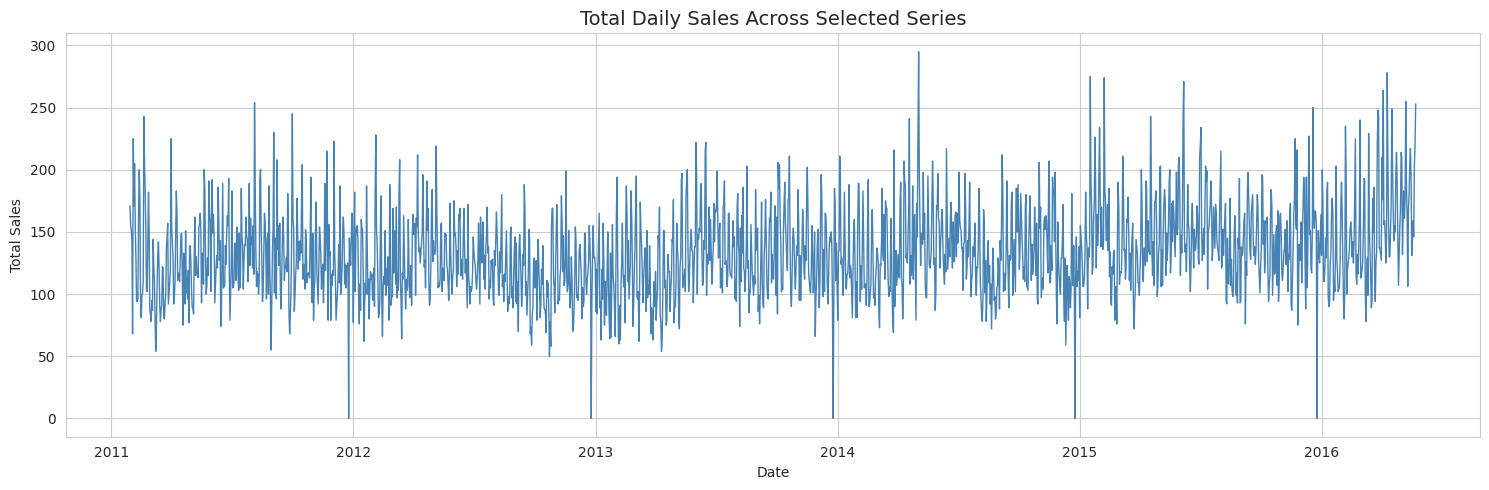

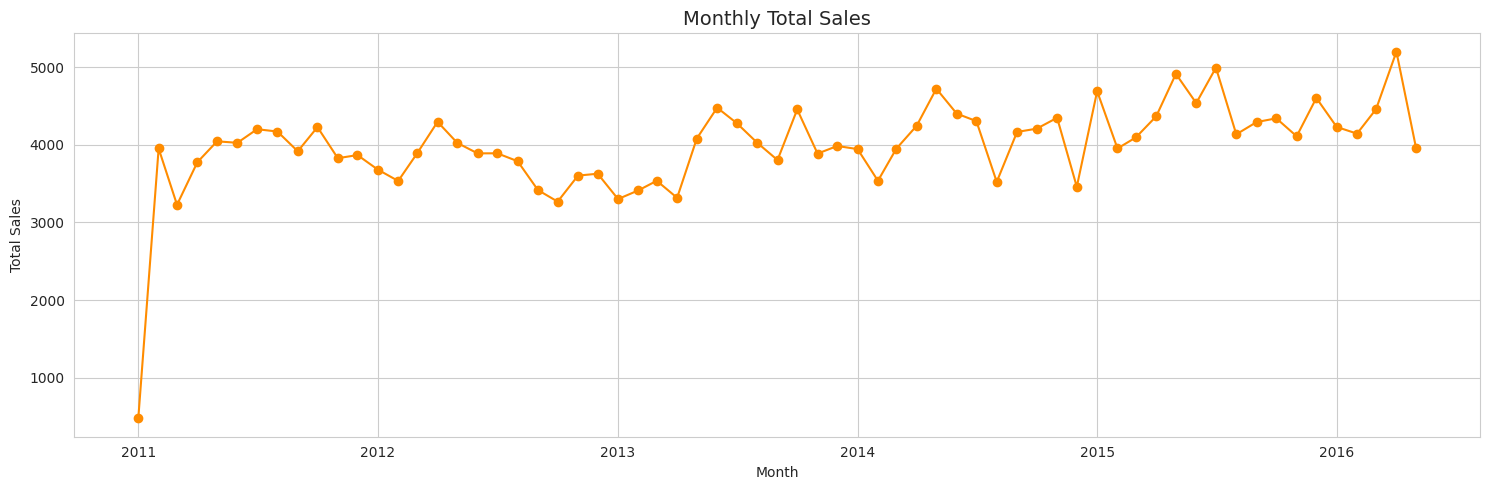

In [9]:
daily_total = long_df.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15,5))
plt.plot(daily_total['date'], daily_total['sales'], color='steelblue', linewidth=1)
plt.title("Total Daily Sales Across Selected Series")
plt.xlabel("Date"); plt.ylabel("Total Sales")
plt.tight_layout(); plt.show()

# Monthly trend
monthly = long_df.groupby(long_df['date'].dt.to_period('M'))['sales'].sum()
monthly.index = monthly.index.to_timestamp()
plt.figure(figsize=(15,5))
plt.plot(monthly.index, monthly.values, marker='o', color='darkorange')
plt.title("Monthly Total Sales")
plt.xlabel("Month"); plt.ylabel("Total Sales")
plt.tight_layout(); plt.show()

**Cell 10: Chart 2 — Day-of-Week Pattern**

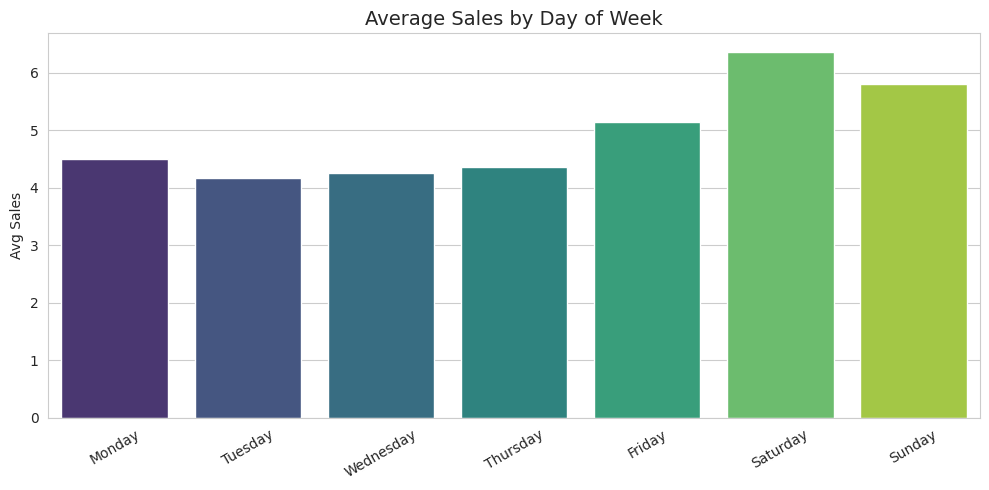

In [10]:
dow = long_df.groupby('weekday')['sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(10,5))
sns.barplot(x=dow.index, y=dow.values, palette='viridis')
plt.title("Average Sales by Day of Week")
plt.ylabel("Avg Sales"); plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

**Cell 11: Chart 3 — Zero-Sales Frequency**

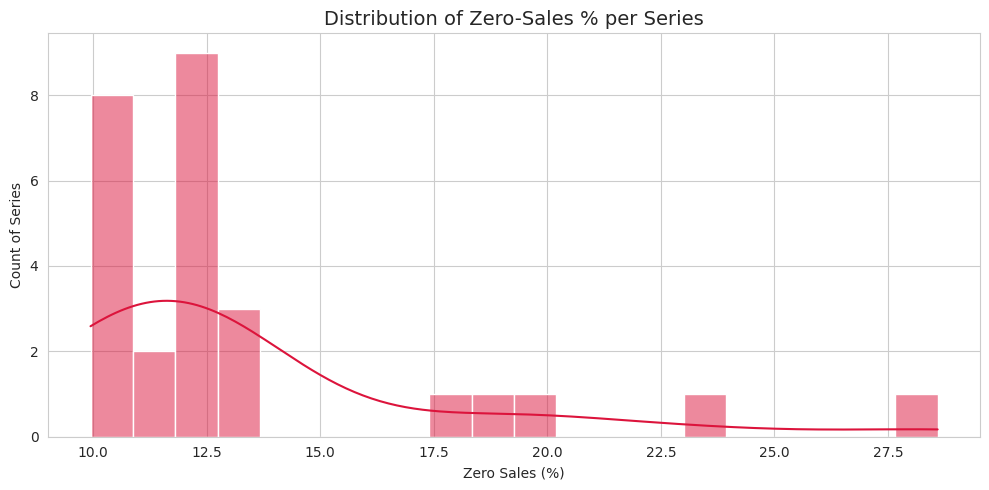

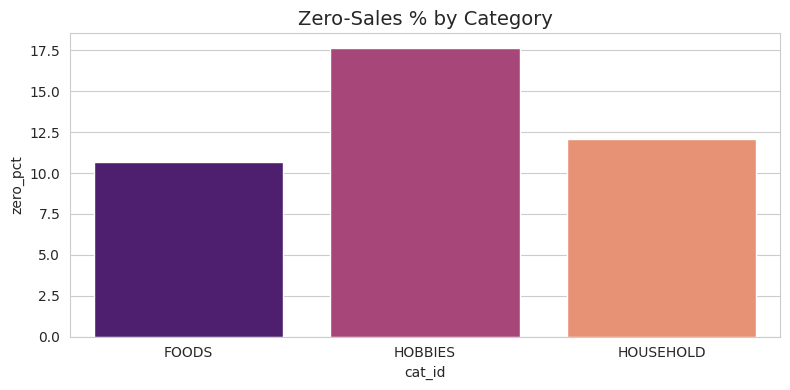

In [11]:
# Overall zero-rate distribution across selected series
zero_by_series = (long_df.groupby(['item_id','store_id'])['sales']
                  .apply(lambda s: (s == 0).mean()*100)
                  .reset_index(name='zero_pct'))

plt.figure(figsize=(10,5))
sns.histplot(zero_by_series['zero_pct'], bins=20, kde=True, color='crimson')
plt.title("Distribution of Zero-Sales % per Series")
plt.xlabel("Zero Sales (%)"); plt.ylabel("Count of Series")
plt.tight_layout(); plt.show()

# Zero-rate by category
zero_cat = (long_df.groupby('cat_id')['sales']
            .apply(lambda s: (s == 0).mean()*100)
            .reset_index(name='zero_pct'))
plt.figure(figsize=(8,4))
sns.barplot(data=zero_cat, x='cat_id', y='zero_pct', palette='magma')
plt.title("Zero-Sales % by Category")
plt.tight_layout(); plt.show()

**Cell 12: Chart 4 — Variability Across Products and Stores**

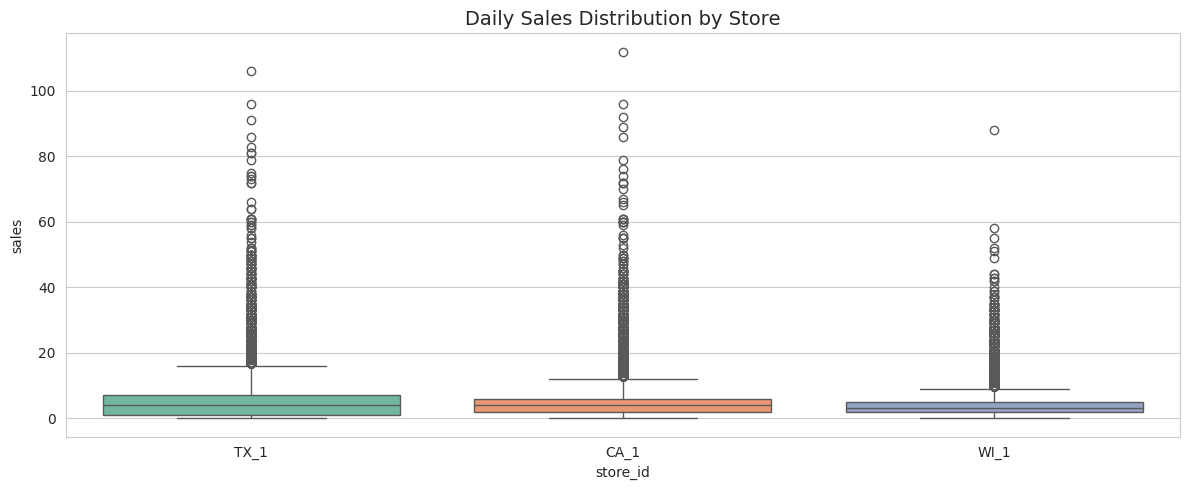

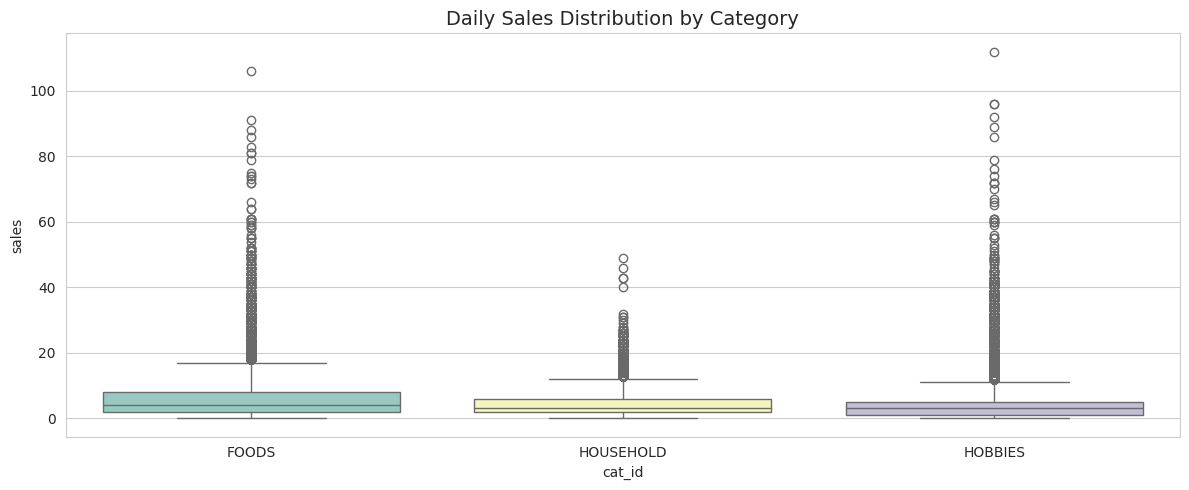

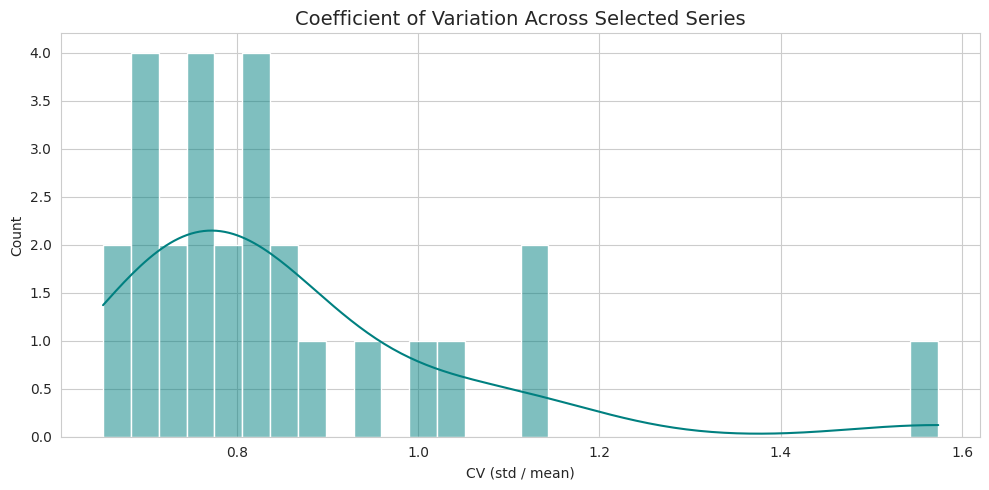

In [12]:
# Boxplot of daily sales by store
plt.figure(figsize=(12,5))
sns.boxplot(data=long_df, x='store_id', y='sales', palette='Set2')
plt.title("Daily Sales Distribution by Store")
plt.tight_layout(); plt.show()

# Boxplot of daily sales by category
plt.figure(figsize=(12,5))
sns.boxplot(data=long_df, x='cat_id', y='sales', palette='Set3')
plt.title("Daily Sales Distribution by Category")
plt.tight_layout(); plt.show()

# Coefficient of variation per series (variability)
cv = (long_df.groupby(['item_id','store_id'])['sales']
      .agg(['mean','std'])
      .assign(cv=lambda x: x['std'] / x['mean'].replace(0, np.nan))
      .reset_index())

plt.figure(figsize=(10,5))
sns.histplot(cv['cv'].dropna(), bins=30, kde=True, color='teal')
plt.title("Coefficient of Variation Across Selected Series")
plt.xlabel("CV (std / mean)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

**Cell 13: Bonus — Price vs Sales Relationshi**p

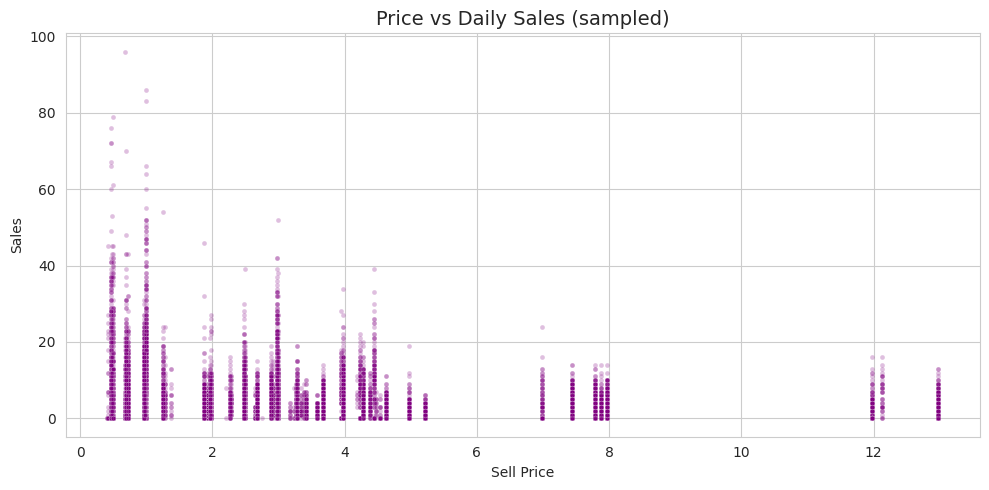


Correlation between price and sales by category:
   cat_id  corr_price_sales
    FOODS         -0.259096
  HOBBIES         -0.257513
HOUSEHOLD         -0.131147


In [13]:
# Aggregate daily price and sales per series, then scatter
price_sales = (long_df.dropna(subset=['sell_price'])
               .groupby(['item_id','store_id','date'])
               .agg(sales=('sales','sum'), price=('sell_price','mean'))
               .reset_index())

plt.figure(figsize=(10,5))
sns.scatterplot(data=price_sales.sample(min(20000, len(price_sales)), random_state=42),
                x='price', y='sales', alpha=0.25, s=12, color='purple')
plt.title("Price vs Daily Sales (sampled)")
plt.xlabel("Sell Price"); plt.ylabel("Sales")
plt.tight_layout(); plt.show()

# Correlation by category
corr = (long_df.dropna(subset=['sell_price'])
        .groupby('cat_id')
        .apply(lambda g: g['sell_price'].corr(g['sales']))
        .reset_index(name='corr_price_sales'))
print("\nCorrelation between price and sales by category:")
print(corr.to_string(index=False))

**Cell 14: Save Cleaned Long-Format Dataset**

In [14]:
OUT_PATH = f"{DATA_PATH}/m5_long_selected.csv"
long_df.to_csv(OUT_PATH, index=False)
print("Saved cleaned long-format data to:", OUT_PATH)
print("Final shape:", long_df.shape)
print("\nColumns:", list(long_df.columns))

Saved cleaned long-format data to: /content/drive/MyDrive/AAI_USD_P1/m5-forecasting-accuracy/m5_long_selected.csv
Final shape: (52407, 21)

Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'zero_rate', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price']
